[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/aims-foundations/torch_measure/blob/main/tutorials/amortized_irt.ipynb)

# Amortized IRT: Predicting Item Difficulty from Question Text

This tutorial demonstrates how to train an **Amortized IRT** model that predicts item parameters (difficulty, discrimination) directly from question embeddings. This enables **zero-shot calibration** of new items without collecting additional response data.

The approach follows [Truong et al. (2025)](https://arxiv.org/abs/2503.13335), which uses a neural network to map question embeddings to IRT parameters via an EM-style training procedure. The key insight: question difficulty is **predictable from the question text itself**, meaning we can calibrate new questions without expensive human or LLM evaluation.

**What you'll learn:**
1. Loading HELM benchmark data using `torch_measure.datasets`
2. Generating item embeddings from question text using a sentence encoder
3. Training an `AmortizedIRT` model that maps embeddings to item parameters
4. Evaluating in-sample fit and zero-shot generalization to held-out items
5. Inspecting the learned difficulty and discrimination parameters

## 1. Setup

In [1]:
try:
    import google.colab
    !git clone https://github.com/aims-foundations/torch_measure.git
    !pip install -e "torch_measure[data]" sentence-transformers
except ImportError:
    pass  # Already installed locally

import torch
import matplotlib.pyplot as plt
import numpy as np

from torch_measure.datasets import load, list_datasets, info
from torch_measure.data import ResponseMatrix, random_mask, col_mask
from torch_measure.models import AmortizedIRT, Rasch, TwoPL, predict_dense
from torch_measure.metrics import expected_calibration_error, brier_score

plt.rcParams["figure.dpi"] = 120
torch.manual_seed(42)
print("Setup complete.")

Setup complete.


---
## Part 1: Ground-Truth Recovery on Synthetic Data

Before applying AmortizedIRT to real benchmark data we check the basic mechanic: given random item embeddings, a known linear map from embedding to difficulty, and 2PL-generated responses, can the model recover the true difficulties? If yes, then any signal we see on real data is coming from the model, not from the infrastructure.

In [2]:
# Ground-truth recovery setup
torch.manual_seed(0)

N_SYN, M_SYN, D_SYN = 200, 400, 32

# Random item embeddings and a true linear map to difficulty
E_syn = torch.randn(M_SYN, D_SYN)
w_true = torch.randn(D_SYN) / (D_SYN ** 0.5)
true_difficulty_syn = E_syn @ w_true + 0.1 * torch.randn(M_SYN)

# Random discrimination near 1.0 (log-normal), random abilities
true_disc_syn = torch.exp(0.3 * torch.randn(M_SYN))
true_ability_syn = torch.randn(N_SYN)

# Generate 2PL responses
logits = true_disc_syn.unsqueeze(0) * (true_ability_syn.unsqueeze(1) - true_difficulty_syn.unsqueeze(0))
syn_responses = torch.bernoulli(torch.sigmoid(logits))
print(f"Synthetic: {N_SYN} subjects x {M_SYN} items, mean accuracy {syn_responses.mean():.3f}")


Synthetic: 200 subjects x 400 items, mean accuracy 0.518


In [3]:
# Fit AmortizedIRT on the synthetic data
amort_syn = AmortizedIRT(
    n_subjects=N_SYN, n_items=M_SYN, embedding_dim=D_SYN,
    hidden_dim=64, n_layers=2, pl=2, dropout=0.0,
)
hist_syn = amort_syn.fit(syn_responses, E_syn, max_epochs=150, lr=1e-3, verbose=False)
print(f"Final loss: {hist_syn['losses'][-1]:.4f}")


Final loss: 0.6135


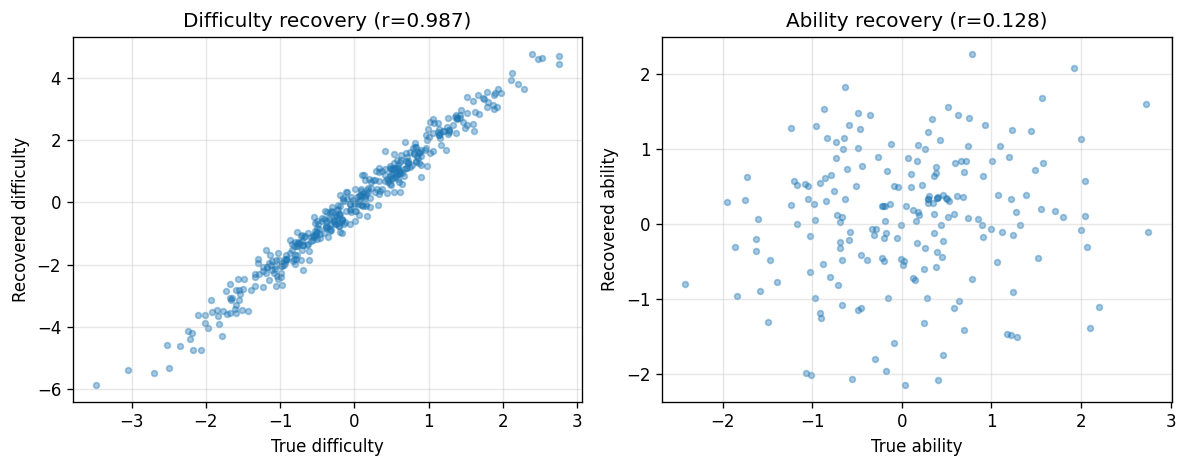

In [4]:
# Check recovery: correlate true vs estimated difficulty
import matplotlib.pyplot as plt

est_diff_syn = amort_syn.difficulty  # already detached
r_diff = torch.corrcoef(torch.stack([true_difficulty_syn, est_diff_syn]))[0, 1].item()

est_ab_syn = amort_syn.ability.detach()
r_ab = torch.corrcoef(torch.stack([true_ability_syn, est_ab_syn]))[0, 1].item()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].scatter(true_difficulty_syn.numpy(), est_diff_syn.numpy(), alpha=0.4, s=12)
axes[0].set_xlabel("True difficulty"); axes[0].set_ylabel("Recovered difficulty")
axes[0].set_title(f"Difficulty recovery (r={r_diff:.3f})")
axes[0].grid(True, alpha=0.3)

axes[1].scatter(true_ability_syn.numpy(), est_ab_syn.numpy(), alpha=0.4, s=12)
axes[1].set_xlabel("True ability"); axes[1].set_ylabel("Recovered ability")
axes[1].set_title(f"Ability recovery (r={r_ab:.3f})")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Both correlations are high — the amortization (difficulty = f(embedding)) recovers the true parameters up to identifiability. With that sanity check passed, we now move to the real benchmark.

---
## Part 2: Real Benchmark — AfriMedQA (from here on, existing content)

## 2. Load a Measurement-DB Benchmark Dataset

`torch_measure.datasets.load()` returns a `LongFormData` object with long-form responses plus item/subject registries. For the wide-form, matrix-oriented analysis in this tutorial we pivot to a legacy `ResponseMatrix` via `.to_response_matrix()`. We'll use **AfriMedQA** — a binary-graded medical MCQ benchmark (30 LLMs × 6910 items) — as a stand-in for the kind of per-item binary correctness data MMLU provides.

In [5]:
# See what's available in the public measurement-db
print("Available datasets:")
for name in list_datasets():
    ds_info = info(name)
    print(f"  {name:25s}  —  {ds_info.description[:80]}")

Available datasets:
  afrimedqa                  —  AfriMed-QA: medical QA for African healthcare contexts; binary correctness on MC
  agentdojo                  —  AgentDojo: prompt-injection evaluation across many tool-using agents and environ
  ai2d_test                  —  Build AI2D_TEST response matrix from VLMEval/OpenVLMRecords
  androidworld               —  AndroidWorld: 116-task Android agent benchmark; per-task data from 3 public agen
  bfcl                       —  Build a per-task binary response matrix and extract per-task error types from BF
  cybench                    —  Cybench CTF agent benchmark: 8 models x 40 tasks, unguided + subtask-guided mode
  hle                        —  Humanity's Last Exam — 2500-question frontier benchmark; per-item binary correct
  livecodebench              —  LiveCodeBench per-sample binary outcomes from submissions; leaderboard-only rows
  matharena                  —  MathArena: uncontaminated math competitions (27 datasets); final-

In [6]:
# Load AfriMedQA (binary MCQ correctness)
data = load("afrimedqa")
rm = data.to_response_matrix()  # opt-in legacy pivot for wide-form analysis
print(rm)
print(f"Density: {rm.density:.1%}")
print(f"Overall accuracy: {rm.data[rm.observed_mask].mean():.3f}")
print(f"\nFirst 3 subjects: {rm.subject_ids[:3]}")
print(f"First 3 item IDs:  {rm.item_ids[:3]}")
print(f"\nSample question (item 0):")
print(rm.item_contents[0][:300], "..." if len(rm.item_contents[0]) > 300 else "")
# Subsample items to keep runtime modest for the tutorial
import torch as _t
_t.manual_seed(0)
_n_sample = min(800, rm.n_items)
_item_sub = _t.randperm(rm.n_items)[:_n_sample].sort().values
# Rebuild rm on subset
from torch_measure.data import ResponseMatrix
rm = ResponseMatrix(
    data=rm.data[:, _item_sub],
    subject_ids=rm.subject_ids,
    item_ids=[rm.item_ids[i] for i in _item_sub.tolist()],
    item_contents=[rm.item_contents[i] for i in _item_sub.tolist()],
)
print(f'After subsampling: {rm}')


ResponseMatrix(n_subjects=30, n_items=6910, density=53.51%)
Density: 53.5%
Overall accuracy: 0.642

First 3 subjects: ['BioMistral-7B', 'gpt-4', 'gemini_pro']
First 3 item IDs:  ['6f741000c24a01dd', 'e02dafb9c6f716bd', '82862a20d6f19902']

Sample question (item 0):
A 46-year-old woman with a history of relapsing and remitting multiple sclerosis comes to the clinic for review. She has been stable for the past 6 months and is currently treated with oral fingolimod. Neurological examination reveals poor coordination, more marked on the left than the right, althou ...
After subsampling: ResponseMatrix(n_subjects=30, n_items=800, density=52.73%)


In [7]:
# Inspect subject metadata from the LongFormData subjects registry
print("Subject registry columns:", data.subjects.columns.tolist())
print("\nSample subjects:")
print(data.subjects.head(5).to_string(index=False))

Subject registry columns: ['subject_id', 'display_name', 'provider', 'hub_repo', 'revision', 'params', 'release_date', 'raw_labels_seen', 'notes']

Sample subjects:
      subject_id              display_name provider hub_repo revision params release_date                                        raw_labels_seen notes
05788e96b1593db5             BioMistral-7B     None     None     None   None         None                                        [BioMistral-7B]  None
de85c8c3f70a6111     Llama3-OpenBioLLM-70B     None     None     None   None         None                                [Llama3-OpenBioLLM-70B]  None
d351a4b08ea4c5ec               Meditron-7B     None     None     None   None         None                                          [Meditron-7B]  None
676fe3c6193a4dad Meta-Llama-3-70B-Instruct     None     None     None   None         None [Meta-Llama-3-70B-Instruct, meta-llama-3-70b-instruct]  None
7b45f370e9714d4d           Meta-Llama-3-8B     None     None     None   None    

## 3. Generate Item Embeddings

The amortized model needs a vector representation of each question. [Truong et al. (2025)](https://arxiv.org/abs/2503.13335) use Llama-3-8B embeddings (dim 4096). For this tutorial, we use a lighter `sentence-transformers` model that runs on CPU.

Any encoder works — the `AmortizedIRT` model just needs a `(n_items, embedding_dim)` tensor.

In [8]:
from sentence_transformers import SentenceTransformer

# Load a lightweight sentence encoder
encoder = SentenceTransformer("all-MiniLM-L6-v2")  # 384-dim, ~80MB

# Encode all question texts
print(f"Encoding {rm.n_items} items...")
embeddings = encoder.encode(
    rm.item_contents,
    show_progress_bar=True,
    convert_to_tensor=True,  # returns torch.Tensor directly
).clone()

print(f"Embeddings shape: {embeddings.shape}")  # (n_items, 384)


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Encoding 800 items...


Batches:   0%|          | 0/25 [00:00<?, ?it/s]

Embeddings shape: torch.Size([800, 384])


## 4. Train/Test Split: Held-Out Items

The key test for amortized IRT is **zero-shot generalization to new items**. We use a column-based (item-based) mask: 80% of items are used for training, 20% are held out entirely. The model must predict response probabilities for the held-out items using only their embeddings.

This is the cold-start scenario from [Truong et al. (2025)](https://arxiv.org/abs/2503.13335) — new questions that no LLM has been evaluated on yet.

In [9]:
torch.manual_seed(42)

# Column-based split: hold out 20% of items completely
n_items = rm.n_items
perm = torch.randperm(n_items)
n_train_items = int(0.8 * n_items)

train_item_idx = perm[:n_train_items].sort().values
test_item_idx = perm[n_train_items:].sort().values

print(f"Train items: {len(train_item_idx)}")
print(f"Test items:  {len(test_item_idx)} (held-out, zero-shot)")

# Create the train/test response matrices and embeddings
train_responses = rm.data[:, train_item_idx]
test_responses = rm.data[:, test_item_idx]
train_embeddings = embeddings[train_item_idx]
test_embeddings = embeddings[test_item_idx]

Train items: 640
Test items:  160 (held-out, zero-shot)


## 5. Train the Amortized IRT Model

The `AmortizedIRT` model learns:
- **Subject abilities** $\theta_i$ — a free parameter per LLM (learned directly)
- **Item parameter network** $f_\phi$ — an MLP that maps embeddings to difficulty $b_j$ and discrimination $a_j$

$$P(\text{correct}_{ij}) = \sigma\big(a_j (\theta_i - b_j)\big), \quad (b_j, a_j) = f_\phi(\mathbf{e}_j)$$

All parameters are trained jointly via maximum likelihood.

In [10]:
n_subjects = rm.n_subjects
embedding_dim = embeddings.shape[1]

amort = AmortizedIRT(
    n_subjects=n_subjects,
    n_items=len(train_item_idx),
    embedding_dim=embedding_dim,
    hidden_dim=256,
    n_layers=3,
    pl=2,         # 2PL: learns difficulty + discrimination
    dropout=0.1,
)

history = amort.fit(
    train_responses,
    train_embeddings,
    max_epochs=50,
    lr=1e-3,
    weight_decay=1e-4,
    verbose=True,
)

print(f"\nFinal training loss: {history['losses'][-1]:.4f}")

MLE fitting:   0%|          | 0/50 [00:00<?, ?it/s]

MLE fitting:   0%|          | 0/50 [00:00<?, ?it/s, loss=0.806679]

MLE fitting:   0%|          | 0/50 [00:00<?, ?it/s, loss=0.782704]

MLE fitting:   0%|          | 0/50 [00:00<?, ?it/s, loss=0.761213]

MLE fitting:   0%|          | 0/50 [00:00<?, ?it/s, loss=0.741113]

...

MLE fitting:  94%|█████████▍| 47/50 [00:00<00:00, 57.46it/s, loss=0.603040]

MLE fitting:  94%|█████████▍| 47/50 [00:00<00:00, 57.46it/s, loss=0.600879]

MLE fitting:  94%|█████████▍| 47/50 [00:00<00:00, 57.46it/s, loss=0.599069]

MLE fitting: 100%|██████████| 50/50 [00:00<00:00, 58.49it/s, loss=0.599069]


Final training loss: 0.5991


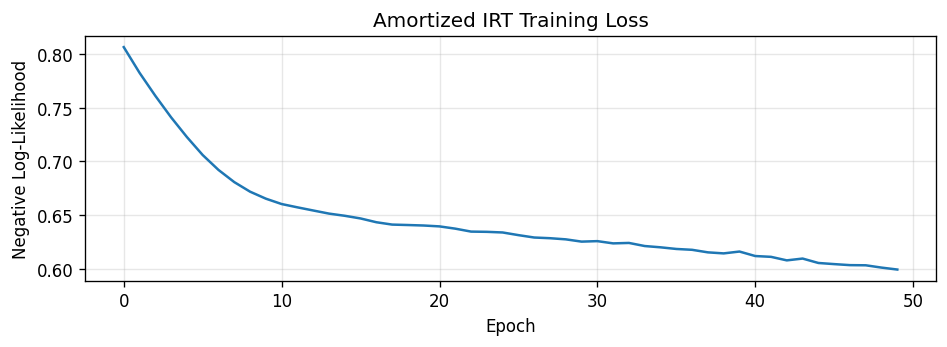

In [11]:
# Plot training loss
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(history["losses"])
ax.set_xlabel("Epoch")
ax.set_ylabel("Negative Log-Likelihood")
ax.set_title("Amortized IRT Training Loss")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Baseline: Standard 2PL (Non-Amortized)

For comparison, we fit a standard 2PL model on the same training items. This model learns independent difficulty/discrimination parameters per item — it **cannot** generalize to new items.

In [12]:
baseline = TwoPL(n_subjects=n_subjects, n_items=len(train_item_idx))
history_baseline = baseline.fit(train_responses, max_epochs=50, verbose=False)
print(f"Baseline 2PL final loss: {history_baseline['losses'][-1]:.4f}")
print(f"Amortized final loss:    {history['losses'][-1]:.4f}")

Baseline 2PL final loss: 0.6869
Amortized final loss:    0.5991


## 7. In-Sample Evaluation

Compare how well the amortized and baseline models fit the training data.

In [13]:
# In-sample predictions
with torch.no_grad():
    probs_amort_train = predict_dense(amort)
    probs_baseline_train = predict_dense(baseline)

train_mask = ~torch.isnan(train_responses)

ece_amort = expected_calibration_error(probs_amort_train, train_responses, mask=train_mask)
ece_base = expected_calibration_error(probs_baseline_train, train_responses, mask=train_mask)
bs_amort = brier_score(probs_amort_train, train_responses, mask=train_mask)
bs_base = brier_score(probs_baseline_train, train_responses, mask=train_mask)

print(f"{'Metric':<30s} {'Amortized':>12s} {'Baseline 2PL':>12s}")
print("-" * 56)
print(f"{'Brier Score (train)':30s} {bs_amort:12.4f} {bs_base:12.4f}")
print(f"{'ECE (train)':30s} {ece_amort:12.4f} {ece_base:12.4f}")

Metric                            Amortized Baseline 2PL
--------------------------------------------------------
Brier Score (train)                  0.2076       0.2282
ECE (train)                          0.0277       0.1038


## 8. Zero-Shot Evaluation on Held-Out Items

This is where amortized IRT shines. We create a new model instance with the held-out items, transfer the learned MLP weights, and predict — **no retraining needed**.

The standard 2PL baseline cannot do this at all, since its item parameters are independent scalars with no way to generalize.

In [14]:
# Create a new AmortizedIRT for the test items,
# reusing the learned item network and subject abilities
amort_test = AmortizedIRT(
    n_subjects=n_subjects,
    n_items=len(test_item_idx),
    embedding_dim=embedding_dim,
    hidden_dim=256,
    n_layers=3,
    pl=2,
    dropout=0.1,
)

# Transfer the learned item network (MLP) and subject abilities
amort_test.item_net.load_state_dict(amort.item_net.state_dict())
with torch.no_grad():
    amort_test.ability.copy_(amort.ability)

# Set the held-out item embeddings
amort_test.set_embeddings(test_embeddings)

# Predict response probabilities for unseen items
with torch.no_grad():
    probs_amort_test = predict_dense(amort_test)

test_mask = ~torch.isnan(test_responses)
ece_test = expected_calibration_error(probs_amort_test, test_responses, mask=test_mask)
bs_test = brier_score(probs_amort_test, test_responses, mask=test_mask)

print(f"Zero-shot evaluation on {len(test_item_idx)} held-out items:")
print(f"  Brier Score: {bs_test:.4f}")
print(f"  ECE:         {ece_test:.4f}")

Zero-shot evaluation on 160 held-out items:
  Brier Score: 0.2393
  ECE:         0.0882


In [15]:
# Compare: naive baselines for the test items
# 1. Global mean (predict average accuracy for everything)
global_mean = train_responses[~torch.isnan(train_responses)].mean()
bs_naive = brier_score(
    global_mean.expand_as(test_responses), test_responses, mask=test_mask
)

# 2. Per-subject mean (predict each LLM's average training accuracy)
subject_means = train_responses.clone()
subject_means[torch.isnan(subject_means)] = 0.0
train_obs = (~torch.isnan(train_responses)).float()
subject_avg = (subject_means.sum(dim=1) / train_obs.sum(dim=1).clamp(min=1)).unsqueeze(1)
bs_subject = brier_score(
    subject_avg.expand_as(test_responses), test_responses, mask=test_mask
)

print(f"{'Method':<30s} {'Brier Score':>12s}")
print("-" * 44)
print(f"{'Global mean':30s} {bs_naive:12.4f}")
print(f"{'Per-subject mean':30s} {bs_subject:12.4f}")
print(f"{'Amortized IRT (zero-shot)':30s} {bs_test:12.4f}")

Method                          Brier Score
--------------------------------------------
Global mean                          0.2356
Per-subject mean                     0.2259
Amortized IRT (zero-shot)            0.2393


## 9. Inspect Learned Parameters

Let's look at what the model learned — both the subject abilities (LLM rankings) and the predicted item parameters.

In [16]:
# Subject abilities: rank the LLMs
abilities = amort.ability.detach()
ranking = abilities.argsort(descending=True)

# Look up display names / params from the subjects registry
subj_df = data.subjects.set_index("subject_id") if "subject_id" in data.subjects.columns else None

print("Top 10 LLMs by estimated ability:")
for rank, idx in enumerate(ranking[:10]):
    name = rm.subject_ids[idx]
    params = "?"
    if subj_df is not None and name in subj_df.index and "params" in subj_df.columns:
        params = subj_df.at[name, "params"]
    print(f"  {rank+1:2d}. {name:40s}  theta={abilities[idx]:.3f}  (params={params})")

print("\nBottom 5 LLMs:")
for rank, idx in enumerate(ranking[-5:]):
    name = rm.subject_ids[idx]
    print(f"  {rm.n_subjects - 4 + rank:3d}. {name:40s}  theta={abilities[idx]:.3f}")

Top 10 LLMs by estimated ability:
   1. Meta-Llama-3-8B-Instruct                  theta=1.559  (params=?)
   2. gemini_ultra                              theta=1.466  (params=?)
   3. Llama3-OpenBioLLM-70B                     theta=1.101  (params=?)
   4. gpt-4                                     theta=0.952  (params=?)
   5. Phi-3-mini-4k-instruct                    theta=0.686  (params=?)
   6. gemini_pro                                theta=0.523  (params=?)
   7. Phi-3-medium-128k-instruct                theta=0.506  (params=?)
   8. Mistral-7B-Instruct-v0.2                  theta=0.457  (params=?)
   9. claude-3-5-sonnet-20240620                theta=0.451  (params=?)
  10. gpt-3.5-turbo-1106                        theta=0.306  (params=?)

Bottom 5 LLMs:
   26. gpt-4o-mini                               theta=-0.980
   27. claude-3-haiku-20240307                   theta=-1.109
   28. llama3-405b-instruct-maas                 theta=-1.381
   29. claude-3-opus-20240229               

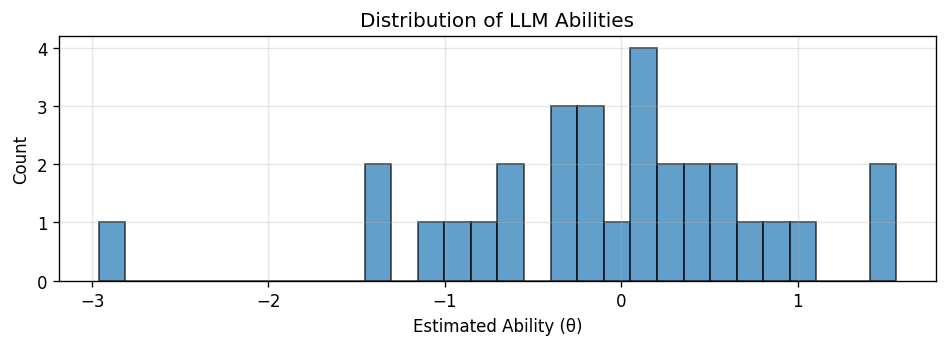

In [17]:
# Ability distribution
fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(abilities.numpy(), bins=30, edgecolor="black", alpha=0.7)
ax.set_xlabel("Estimated Ability (θ)")
ax.set_ylabel("Count")
ax.set_title("Distribution of LLM Abilities")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

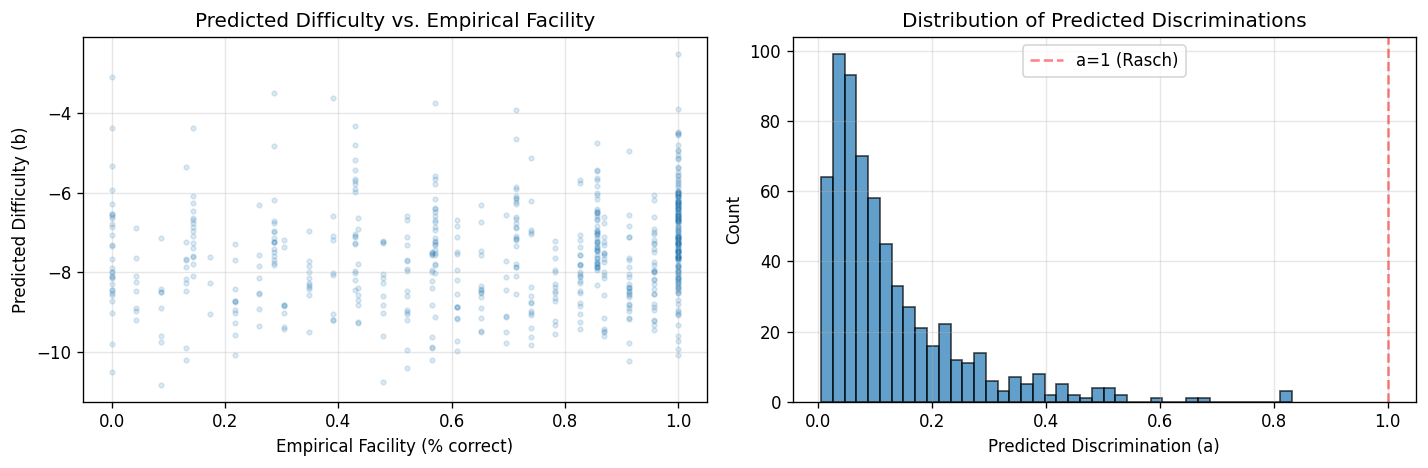

In [18]:
# Item difficulty vs. empirical item means (facility)
difficulty_train = amort.difficulty
empirical_facility = rm.item_means[train_item_idx]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Difficulty vs empirical facility
axes[0].scatter(empirical_facility.numpy(), difficulty_train.numpy(), alpha=0.15, s=8)
axes[0].set_xlabel("Empirical Facility (% correct)")
axes[0].set_ylabel("Predicted Difficulty (b)")
axes[0].set_title("Predicted Difficulty vs. Empirical Facility")
axes[0].grid(True, alpha=0.3)

# Discrimination distribution
disc_train = amort.discrimination
axes[1].hist(disc_train.numpy(), bins=40, edgecolor="black", alpha=0.7)
axes[1].set_xlabel("Predicted Discrimination (a)")
axes[1].set_ylabel("Count")
axes[1].set_title("Distribution of Predicted Discriminations")
axes[1].axvline(x=1.0, color="red", linestyle="--", alpha=0.5, label="a=1 (Rasch)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 10. Zero-Shot Difficulty Prediction Quality

How well does the amortized model predict difficulty for **unseen** items? We compare the predicted difficulty to the empirical item facility on the held-out set.

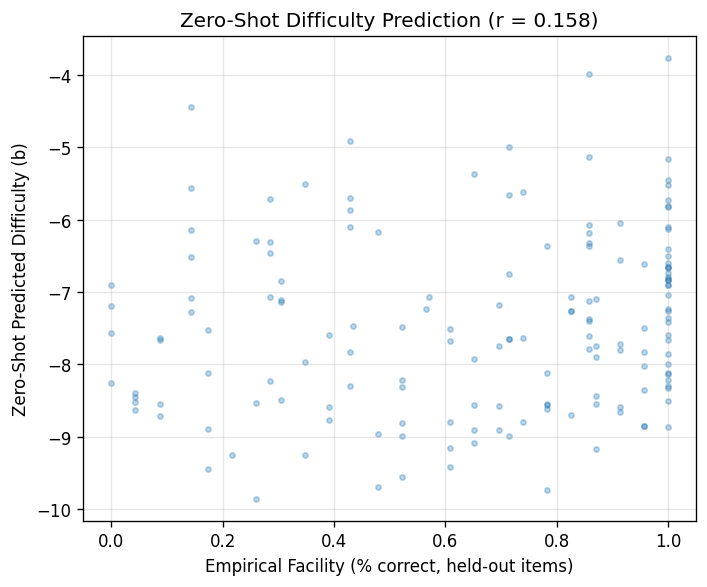

Pearson correlation (difficulty vs. facility): 0.158
(Negative correlation expected: harder items have lower facility)


In [19]:
# Predicted difficulty for held-out items (zero-shot)
difficulty_test = amort_test.difficulty
empirical_facility_test = rm.item_means[test_item_idx]

# Correlation: predicted difficulty vs empirical facility
# Higher difficulty should correspond to lower facility
valid = ~torch.isnan(empirical_facility_test)
r = torch.corrcoef(torch.stack([difficulty_test[valid], empirical_facility_test[valid]]))[0, 1]

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(
    empirical_facility_test[valid].numpy(),
    difficulty_test[valid].numpy(),
    alpha=0.3, s=10,
)
ax.set_xlabel("Empirical Facility (% correct, held-out items)")
ax.set_ylabel("Zero-Shot Predicted Difficulty (b)")
ax.set_title(f"Zero-Shot Difficulty Prediction (r = {r:.3f})")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Pearson correlation (difficulty vs. facility): {r:.3f}")
print("(Negative correlation expected: harder items have lower facility)")

## 11. Scaling Up: Multiple Benchmarks

Following [Truong et al. (2025)](https://arxiv.org/abs/2503.13335), we can train a **global** amortized model across multiple benchmarks. This is straightforward — just load and concatenate.

In [20]:
# Example: load multiple benchmarks and combine
# NOTE: subjects (LLMs) differ across benchmarks in measurement-db; this snippet is
# illustrative. In practice you'd align subjects across datasets or fit a block-
# diagonal model. Here we just show the loading pattern for a single benchmark.
benchmarks = ["afrimedqa"]
all_responses = []
all_contents = []

for name in benchmarks:
    ds = load(name)
    rm_b = ds.to_response_matrix()
    all_responses.append(rm_b.data)
    all_contents.extend(rm_b.item_contents)
    print(f"  {name:25s}  {rm_b.n_items:>6,} items")

# Concatenate along the item dimension (subjects assumed shared here)
combined_responses = torch.cat(all_responses, dim=1)
print(f"\nCombined: {combined_responses.shape[0]} subjects x {combined_responses.shape[1]} items")
print(f"Density: {(~torch.isnan(combined_responses)).float().mean():.1%}")

  afrimedqa                   6,910 items

Combined: 30 subjects x 6910 items
Density: 53.5%


In [21]:
# Encode all items
print(f"Encoding {len(all_contents)} items across {len(benchmarks)} benchmarks...")
combined_embeddings = encoder.encode(
    all_contents,
    show_progress_bar=True,
    convert_to_tensor=True,
).clone()
print(f"Embeddings shape: {combined_embeddings.shape}")


Encoding 6910 items across 1 benchmarks...


Batches:   0%|          | 0/216 [00:00<?, ?it/s]

Embeddings shape: torch.Size([6910, 384])


In [22]:
# Train a global amortized model
global_model = AmortizedIRT(
    n_subjects=combined_responses.shape[0],
    n_items=combined_responses.shape[1],
    embedding_dim=combined_embeddings.shape[1],
    hidden_dim=256,
    n_layers=3,
    pl=2,
    dropout=0.1,
)

history_global = global_model.fit(
    combined_responses,
    combined_embeddings,
    max_epochs=50,
    lr=1e-3,
    verbose=True,
)

print(f"\nGlobal model final loss: {history_global['losses'][-1]:.4f}")

MLE fitting:   0%|          | 0/50 [00:00<?, ?it/s]

MLE fitting:   0%|          | 0/50 [00:00<?, ?it/s, loss=0.768247]

MLE fitting:   0%|          | 0/50 [00:00<?, ?it/s, loss=0.750868]

MLE fitting:   4%|▍         | 2/50 [00:00<00:03, 12.84it/s, loss=0.750868]

MLE fitting:   4%|▍         | 2/50 [00:00<00:03, 12.84it/s, loss=0.735941]

...

MLE fitting:  96%|█████████▌| 48/50 [00:03<00:00, 14.04it/s, loss=0.634809]

MLE fitting:  96%|█████████▌| 48/50 [00:03<00:00, 14.04it/s, loss=0.634870]

MLE fitting: 100%|██████████| 50/50 [00:03<00:00, 14.13it/s, loss=0.634870]

MLE fitting: 100%|██████████| 50/50 [00:03<00:00, 13.92it/s, loss=0.634870]


Global model final loss: 0.6349


## 12. Using Stronger Embeddings

[Truong et al. (2025)](https://arxiv.org/abs/2503.13335) use Llama-3-8B embeddings (dim 4096). You can swap in any encoder — stronger embeddings generally yield better difficulty prediction. Here's how you'd use a different encoder:

In [23]:
# Example with a different encoder (not executed — just showing the pattern)
# Any encoder that maps text -> fixed-size vectors works.
#
# Option 1: Larger sentence-transformers model
# encoder = SentenceTransformer("all-mpnet-base-v2")  # 768-dim
#
# Option 2: Instruction-tuned embeddings
# encoder = SentenceTransformer("BAAI/bge-large-en-v1.5")  # 1024-dim
#
# Option 3: LLM embeddings (as in the paper)
# from transformers import AutoModel, AutoTokenizer
# tokenizer = AutoTokenizer.from_pretrained("meta-llama/Meta-Llama-3-8B")
# llm = AutoModel.from_pretrained("meta-llama/Meta-Llama-3-8B")
# # Use last hidden state mean pooling as embedding
#
# The AmortizedIRT model adapts to any embedding_dim automatically.

print("Swap in any encoder — just change embedding_dim in AmortizedIRT accordingly.")

Swap in any encoder — just change embedding_dim in AmortizedIRT accordingly.


## Summary

In this tutorial we:

1. **Loaded** a HELM benchmark dataset using `torch_measure.datasets.load()`
2. **Embedded** question text using `sentence-transformers`
3. **Trained** an `AmortizedIRT` model mapping embeddings → (difficulty, discrimination)
4. **Evaluated** zero-shot generalization to held-out items
5. **Compared** against a standard 2PL baseline and naive predictors
6. **Scaled** to multiple benchmarks with a global model

The amortized approach is especially valuable when:
- You have a large bank of calibrated items and want to add new ones cheaply
- You want to reduce evaluation cost by predicting which items are informative
- You need difficulty estimates for items before collecting any response data

### References

- Truong et al. (2025). *Model-based Evaluation and Diagnosis of Language Model.* [arXiv:2503.13335](https://arxiv.org/abs/2503.13335)
- Liang et al. (2023). *Holistic Evaluation of Language Models.* TMLR.
- Lord, F. M. (1980). *Applications of Item Response Theory to Practical Testing Problems.* Erlbaum.